# AI LÀ AI

Notebook baseline tạo trực tiếp `submission.zip` cho tập kiểm tra.

## 1. Cấu hình

In [24]:
# !unzip -P 629436 -q /kaggle/input/datasets/phnguyencs/qa-dataset/TACVU1/data/private_test.zip

In [25]:
import os

# Phải đặt trước khi torch khởi tạo CUDA.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import random
import time
import zipfile
from torchvision import models
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2

TRAIN_ROOT = Path('/kaggle/input/datasets/phnguyencs/qa-dataset/TACVU1/data')
TEST_ROOT = Path('/kaggle/working/private_test')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Cố định kết quả giữa các lần chạy: cùng seed -> cùng file nộp.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[cấu hình] thiết bị: {DEVICE}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))

[cấu hình] thiết bị: cuda (Tesla T4)


## 2. Mô hình và phép biến đổi ảnh

In [26]:
backbone = models.efficientnet_b0(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s] 


In [27]:
dim = backbone.classifier[1].in_features
print(dim)

1280


In [28]:
backbone.classifier[1] = nn.Linear(dim, 2)
backbone.classifier[0] = nn.Dropout(0.3)

In [29]:
feature_modules = nn.Sequential(*list(backbone.children())[:-1])
head_module = list(backbone.children())[-1]
print(len(feature_modules), len(head_module))
param_groups = [
    {
        'params': feature_modules.parameters(),
        'lr': 1e-4,        
        'weight_decay': 1e-2
    },
    {
        'params': head_module.parameters(),
        'lr': 1e-3,       
        'weight_decay': 1e-2
    }
]

2 2


In [30]:
total_params = sum(p.numel() for p in backbone.parameters())
print(total_params)

4010110


In [31]:
train_tf = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.RandomResizedCrop((224, 224), scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomApply([
        v2.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=4)
    ], p=0.35),
    v2.RandomApply([v2.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.8),
    v2.RandomApply([v2.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.2),
    v2.RandomGrayscale(p=0.05),
    v2.ToDtype(torch.float, scale=True),
    v2.Normalize((.485, .456, .406), (.229, .224, .225)),
    v2.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.5, 2.0), value='random')
])
test_tf = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.CenterCrop((224, 224)),
    v2.ToDtype(torch.float, scale=True),
    v2.Normalize((.485, .456, .406), (.229, .224, .225))
])

## 3. Dataset

In [32]:
def load_image(path: Path, tf):
    with Image.open(path) as image:
        return tf(ImageOps.exif_transpose(image).convert('RGB'))


class FaceImages(Dataset):
    """Đọc ảnh khuôn mặt; có nhãn khi huấn luyện, trả tên file khi dự đoán."""

    def __init__(self, rows, root, tf, labeled=True):
        self.rows = rows.reset_index(drop=True)
        self.root = root
        self.tf = tf
        self.labeled = labeled

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        name = Path(row.path).name if self.labeled else row.file_name
        image = load_image(self.root / 'images' / name, self.tf)
        return (image, int(row.label)) if self.labeled else (image, name)


print('[dataset] đã định nghĩa FaceImages (dùng chung cho train và dự đoán)')

[dataset] đã định nghĩa FaceImages (dùng chung cho train và dự đoán)


## 4. Nạp dữ liệu

In [33]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(TRAIN_ROOT / 'train' / 'manifest.csv')
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label']
)

train_data = FaceImages(train_df, TRAIN_ROOT / 'train', train_tf)
val_data = FaceImages(val_df, TRAIN_ROOT / 'train', test_tf)
query = pd.DataFrame({
    'file_name': sorted(p.name for p in (TEST_ROOT / 'images').iterdir() if p.is_file())
})
BATCH_SIZE = 64
LOADER_KWARGS = {
    'batch_size': BATCH_SIZE,
    'pin_memory': True,
    'num_workers': 2,
    'persistent_workers': True,
}
train_loader = DataLoader(train_data, shuffle=True, **LOADER_KWARGS)
val_loader = DataLoader(val_data, shuffle=False, **LOADER_KWARGS)
print(f'[dữ liệu] train: {len(train_data):,} ảnh')
print(f'[dữ liệu] val: {len(val_data):,} ảnh')
print(f'[dữ liệu] Test: {len(query):,} ảnh cần dự đoán')
print(f'[dữ liệu] phân bố nhãn train: {train_df.label.value_counts().to_dict()}')

[dữ liệu] train: 1,600 ảnh
[dữ liệu] val: 400 ảnh
[dữ liệu] Test: 200 ảnh cần dự đoán
[dữ liệu] phân bố nhãn train: {1: 800, 0: 800}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35743254..1.4045607].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44800964..1.3507236].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.34781423..1.6122926].


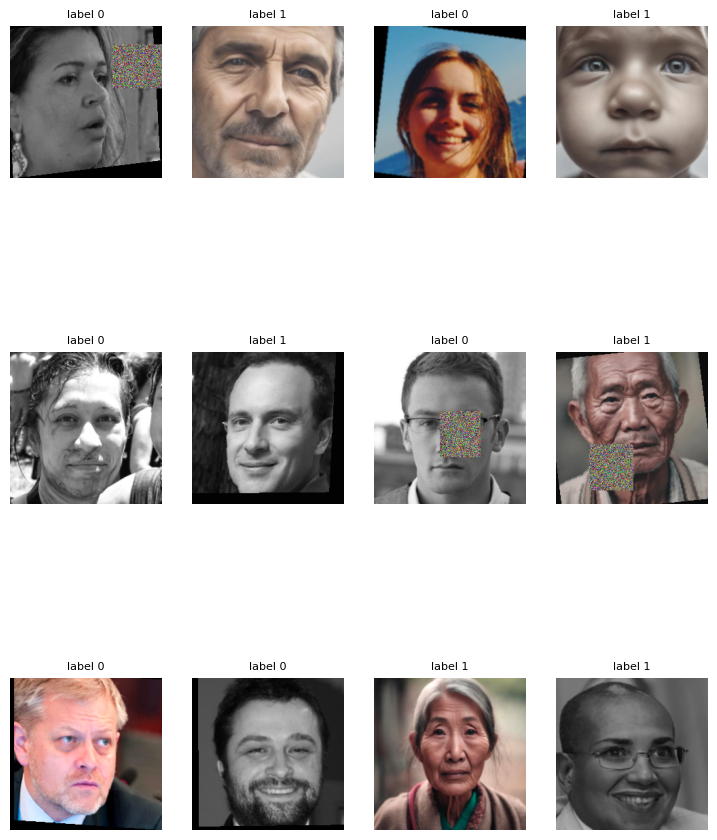

In [34]:
import matplotlib.pyplot as plt
imgs, labels = next(iter(train_loader))
fig, ax = plt.subplots(3, 4, figsize= (9, 12))
ax = ax.flatten()
mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)

for i in range(12):
    img, label = imgs[i], labels[i]
    img = img * std + mean
    img = img.permute(1,2,0).numpy()
    ax[i].imshow(img)
    ax[i].set_title(f"label {label}", fontsize=8)
    ax[i].axis('off')
plt.show()

In [35]:
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support

## 5. Huấn luyện

In [36]:
backbone = backbone.to(DEVICE)
optimizer = torch.optim.AdamW(
    [
        {'params': feature_modules.parameters(), 'lr': 3e-5},
        {'params': head_module.parameters(), 'lr': 3e-4},
    ],
    betas=(0.9, 0.999),
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
best_f1 = -1.0
best_model_path = './best_model.pth'

In [37]:
from torch.nn.utils import clip_grad_norm_

def soft_cross_entropy(logits, target_a, target_b, mix):
    return mix * criterion(logits, target_a) + (1.0 - mix) * criterion(logits, target_b)


def train_epoch(epoch, epochs, train_loader, scheduler):
    backbone.train()
    correct, count = 0, 0
    losses = []
    progress = tqdm(train_loader, desc=f'Train {epoch}/{epochs}')
    for images, labels in progress:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        # MixUp/CutMix regularize only some batches; clean batches preserve the original labels.
        use_mix = random.random() < 0.5
        if use_mix:
            permutation = torch.randperm(images.size(0), device=DEVICE)
            mixed_labels = labels[permutation]
            mix = np.random.beta(0.4, 0.4)
            if random.random() < 0.5:
                images = mix * images + (1.0 - mix) * images[permutation]
            else:
                height, width = images.shape[-2:]
                cut_ratio = np.sqrt(1.0 - mix)
                cut_width, cut_height = int(width * cut_ratio), int(height * cut_ratio)
                center_x = random.randrange(width)
                center_y = random.randrange(height)
                x0 = max(center_x - cut_width // 2, 0)
                x1 = min(center_x + cut_width // 2, width)
                y0 = max(center_y - cut_height // 2, 0)
                y1 = min(center_y + cut_height // 2, height)
                images[:, :, y0:y1, x0:x1] = images[permutation, :, y0:y1, x0:x1]
                mix = 1.0 - ((x1 - x0) * (y1 - y0) / (width * height))
            outputs = backbone(images)
            loss = soft_cross_entropy(outputs, labels, mixed_labels, mix)
        else:
            outputs = backbone(images)
            loss = criterion(outputs, labels)

        loss.backward()
        clip_grad_norm_(backbone.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        pred = outputs.argmax(1)
        correct += (pred == labels).sum().item()
        count += labels.size(0)

    return correct / count, sum(losses) / len(losses)


def evaluate(epoch, epochs, val_loader):
    backbone.eval()
    correct, count = 0, 0
    losses = []
    preds, labels_all = [], []
    with torch.inference_mode():
        for images, labels in tqdm(val_loader, desc=f'Val {epoch}/{epochs}'):
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            outputs = backbone(images)
            losses.append(criterion(outputs, labels).item())
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            count += labels.size(0)
            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_all, preds, average='macro', zero_division=0
    )
    return correct / count, sum(losses) / len(losses), precision, recall, f1

In [38]:
train_accs, train_losses, val_accs, val_losses, f1s = [],[],[],[],[] 

In [39]:
def train_model(epochs, train_loader, val_loader, patience=8):
    global best_f1
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[3e-5, 3e-4],
        total_steps=epochs * len(train_loader),
        pct_start=0.15,
        anneal_strategy='cos',
        div_factor=10,
        final_div_factor=100,
    )
    wait = 0
    for epoch in range(1, epochs + 1):
        train_acc, train_loss = train_epoch(epoch, epochs, train_loader, scheduler)
        val_acc, val_loss, precision, recall, f1 = evaluate(epoch, epochs, val_loader)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        f1s.append(f1)
        print(f'Train Acc: {train_acc:.4f}, Train loss: {train_loss:.4f}')
        print(f'Val Acc: {val_acc:.4f}, Val loss: {val_loss:.4f}')
        print(f'F1: {f1 * 100:.2f}% | Precision: {precision * 100:.2f}% | Recall: {recall * 100:.2f}%')

        if f1 > best_f1:
            best_f1 = f1
            torch.save(backbone.state_dict(), best_model_path)
            wait = 0
            print(f'Checkpoint at epoch {epoch}')
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

In [40]:
# import torch
# import gc

# # 1. Xóa các biến/mô hình đang chiếm VRAM
# del backbone
# # del labels

# # 2. Gọi bộ gom rác của Python
# gc.collect()

# 3. Làm trống bộ nhớ đệm của PyTorch CUDA
# torch.cuda.empty_cache()


In [41]:
train_accs, train_losses, val_accs, val_losses, f1s = [], [], [], [], []
train_model(35, train_loader, val_loader, patience=8)

Val 1/35: 100%|██████████| 7/7 [00:01<00:00,  3.96it/s]


Train Acc: 0.5125, Train loss: 0.6975
Val Acc: 0.5300, Val loss: 0.6904
F1: 51.68% | Precision: 53.37% | Recall: 53.00%
Checkpoint at epoch 1


Val 2/35: 100%|██████████| 7/7 [00:01<00:00,  4.66it/s]


Train Acc: 0.5094, Train loss: 0.6858
Val Acc: 0.5925, Val loss: 0.6719
F1: 59.11% | Precision: 59.37% | Recall: 59.25%
Checkpoint at epoch 2


Val 3/35: 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]


...

Train Acc: 0.8281, Train loss: 0.3808
Val Acc: 0.8200, Val loss: 0.4315
F1: 81.98% | Precision: 82.16% | Recall: 82.00%


Val 34/35: 100%|██████████| 7/7 [00:01<00:00,  4.90it/s]


Train Acc: 0.7881, Train loss: 0.4030
Val Acc: 0.8300, Val loss: 0.4361
F1: 83.00% | Precision: 83.01% | Recall: 83.00%


Val 35/35: 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]

Train Acc: 0.8275, Train loss: 0.3885
Val Acc: 0.8250, Val loss: 0.4312
F1: 82.49% | Precision: 82.58% | Recall: 82.50%


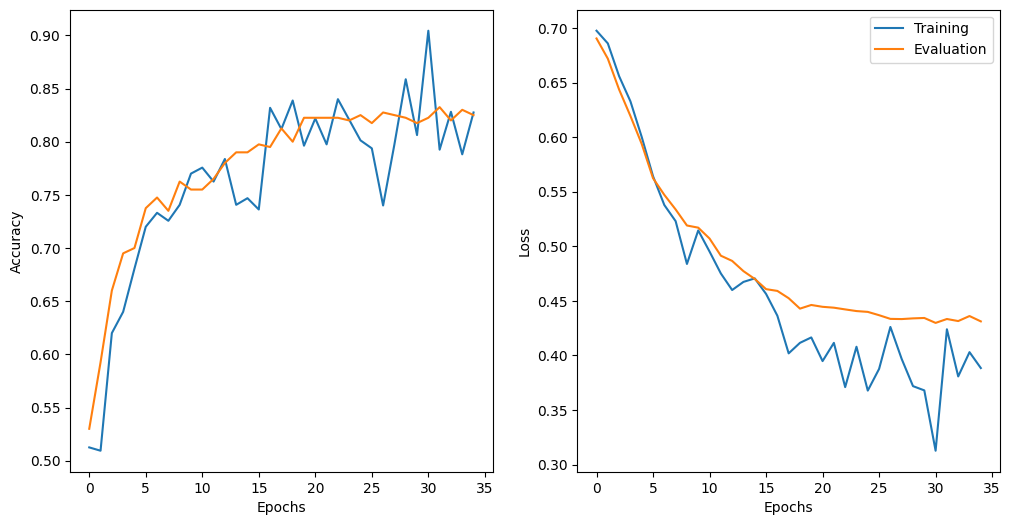

In [42]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
epochs = list(range(len(train_accs)))
axs[0].plot(epochs,train_accs, label = "Training")
axs[0].plot(epochs, val_accs, label = "Evaluation")
axs[1].plot(epochs, train_losses, label = "Training")
axs[1].plot(epochs, val_losses, label = "Evaluation")
axs[0].set_xlabel("Epochs")
axs[1].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Loss")
plt.legend()
plt.savefig('./training_curves.png')
plt.show()

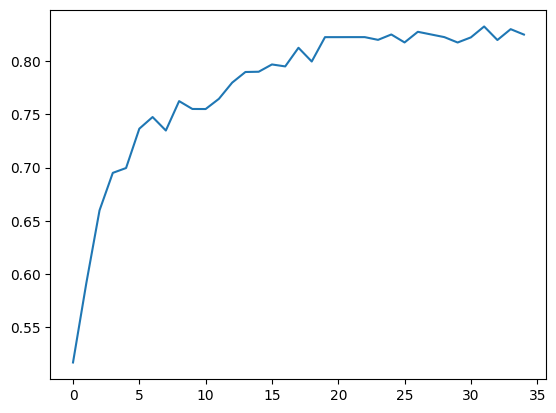

In [43]:
plt.plot(epochs, f1s)

## 6. Dự đoán và đóng gói bài nộp

In [44]:
rows = []
started = time.time()
TTA_ENABLED = True
model = models.efficientnet_b0(weights=None)
model.classifier[0] = nn.Dropout(0.3)
model.classifier[1] = nn.Linear(dim, 2)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model = model.to(DEVICE)
model.eval()
with torch.inference_mode():
    loader = DataLoader(
        FaceImages(query, TEST_ROOT, test_tf, labeled=False), batch_size=BATCH_SIZE,
        pin_memory=DEVICE.type == 'cuda',
    )
    for images, names in loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        if TTA_ENABLED:
            flipped_logits = model(torch.flip(images, dims=(-1,)))
            logits = (logits + flipped_logits) * 0.5
        labels = logits.argmax(1).cpu().tolist()
        rows.extend(zip(names, labels))

submission = pd.DataFrame(rows, columns=['file_name', 'category_id'])
submission.to_csv('submission.csv', index=False)

with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as archive:
    archive.write('submission.csv')

print(f'[dự đoán] {len(submission):,} ảnh trong {time.time() - started:.1f}s')
print(f'[dự đoán] TTA: {TTA_ENABLED} (ảnh gốc + lật ngang)')
print(f'[dự đoán] phân bố nhãn: {submission.category_id.value_counts().to_dict()}')
print('[nộp bài] đã tạo submission.zip (chứa đúng submission.csv ở thư mục gốc)')

[dự đoán] 200 ảnh trong 1.7s
[dự đoán] TTA: True (ảnh gốc + lật ngang)
[dự đoán] phân bố nhãn: {0: 108, 1: 92}
[nộp bài] đã tạo submission.zip (chứa đúng submission.csv ở thư mục gốc)
